# 2장 2강: 퍼널 분석 — 전환율·이탈률 측정 원리 — 실습문제

## 실습 목표

- Ravenstack의 구독 여정을 순차적인 퍼널 단계로 정의할 수 있다.
- 이벤트 횟수와 고유 구독 수의 차이를 설명할 수 있다.
- 단계별 전환율과 이탈률을 계산할 수 있다.
- 막대형 퍼널을 시각화하고 이탈이 집중된 구간을 찾을 수 있다.
- 세그먼트별 퍼널을 비교하고 개선 가설을 제안할 수 있다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- `ravenstack_subscriptions.csv`
- `ravenstack_feature_usage.csv`

이번 실습에서는 Ravenstack의 구독 여정을 다음과 같이 단순화합니다.

| 순서 | 퍼널 단계 | 집계 기준 |
|---:|---|---|
| 1 | 구독 시작 | `subscriptions`에 존재하는 고유 구독 |
| 2 | 기능 사용 | 기능 사용 기록이 한 번 이상 있는 구독 |
| 3 | 유료 구독 | 기능 사용 구독 중 `is_trial == False`인 구독 |
| 4 | 현재 유료 유지 | 이전 단계 구독 중 `end_date`가 비어 있는 구독 |

> 이 퍼널은 전환율 계산 원리를 익히기 위한 학습용 정의입니다. `is_trial`은 실제 유료 전환 시각을 기록한 이벤트가 아니므로 실제 전환 소요 시간이나 행동 순서를 완전히 재구성할 수는 없습니다.

## 실습 준비

1. 필요한 라이브러리를 불러오세요.
2. 두 CSV 파일을 각각 `subscriptions`, `feature_usage`에 불러오세요.
3. 각 데이터의 행과 열 개수, 상위 5개 행을 확인하세요.
4. 분석 대상 컬럼의 자료형과 결측치 개수를 확인하세요.
5. `start_date`, `end_date`, `usage_date`를 날짜형으로 변환하세요.
6. 구독 ID의 고유 개수와 기능 사용 이벤트 행 수를 확인하세요.
7. `usage_id`의 중복 개수를 확인하고, 중복 ID를 바로 삭제하면 안 되는 이유를 생각해보세요.

In [1]:
# 실습 준비 코드를 작성하세요.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

subscriptions = pd.read_csv('ravenstack_subscriptions.csv')
feature_usage = pd.read_csv('ravenstack_feature_usage.csv')

print('[자료 구조]')
print(f'{subscriptions.shape} | {feature_usage.shape}')

print('\n[자료형]')
print(subscriptions.info())
print(feature_usage.info())

print('\n[결측치 개수]')
print(subscriptions.isnull().sum())
print(feature_usage.isnull().sum())

# 자료형 변환
subscriptions['start_date'] = pd.to_datetime(subscriptions['start_date'])
subscriptions['end_date'] = pd.to_datetime(subscriptions['end_date'])
feature_usage['usage_date'] = pd.to_datetime(feature_usage['usage_date'])

# 고유값 개수
print()
print('구독 ID 고유값 개수 :', subscriptions['subscription_id'].nunique())
print('기능 사용 이력 존재하는 ID :', (feature_usage['usage_count']>=1).count())

[자료 구조]
(5000, 14) | (25000, 8)

[자료형]
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   subscription_id    5000 non-null   str  
 1   account_id         5000 non-null   str  
 2   start_date         5000 non-null   str  
 3   end_date           486 non-null    str  
 4   plan_tier          5000 non-null   str  
 5   seats              5000 non-null   int64
 6   mrr_amount         5000 non-null   int64
 7   arr_amount         5000 non-null   int64
 8   is_trial           5000 non-null   bool 
 9   upgrade_flag       5000 non-null   bool 
 10  downgrade_flag     5000 non-null   bool 
 11  churn_flag         5000 non-null   bool 
 12  billing_frequency  5000 non-null   str  
 13  auto_renew_flag    5000 non-null   bool 
dtypes: bool(5), int64(3), str(6)
memory usage: 376.1 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Da

---

## 필수 1. 전체 구독 퍼널의 전환율과 이탈률 계산하기

### 문제 1-1. Ravenstack 구독은 어느 구간에서 가장 많이 이탈하는가?

#### 문제 설명

전체 Ravenstack 구독을 대상으로 네 단계의 고유 구독 수를 계산하고, 각 구간의 전환율과 이탈률을 구하세요.

각 단계는 반드시 앞 단계를 통과한 구독만 포함해야 합니다. 예를 들어 유료 구독 단계는 전체 유료 구독이 아니라 **기능 사용 단계에 포함되면서 유료인 구독**으로 계산합니다.

#### 요구사항

1. 전체 구독 ID를 `started_ids`로 만드세요.
2. 기능 사용 기록이 있는 구독 ID와 `started_ids`의 교집합을 `used_ids`로 만드세요.
3. `used_ids`와 체험이 아닌 구독 ID의 교집합을 `paid_ids`로 만드세요.
4. `paid_ids`와 종료일이 비어 있는 구독 ID의 교집합을 `retained_paid_ids`로 만드세요.
5. 단계명과 고유 구독 수를 사용하여 `funnel` 데이터프레임을 만드세요.
6. 다음 식으로 구간 전환율과 이탈률을 계산하세요.
   - 전환율 = 현재 단계 구독 수 ÷ 이전 단계 구독 수
   - 이탈률 = 1 - 전환율
7. 각 구간의 이탈 구독 수도 계산하세요.
8. 단계별 구독 수를 막대그래프로 시각화하세요.
9. 전환율이 가장 낮은 구간을 찾고 개선 가설을 한 가지 제안하세요.

#### 해석 질문

**Q1.** 기능 사용 이벤트 행 수 대신 고유 구독 수를 사용해야 하는 이유는 무엇인가요?  
**Q2.** 전환율이 가장 낮고 이탈 구독 수가 가장 많은 구간은 어디인가요?  
**Q3.** 전환율과 이탈률을 더하면 얼마인가요?  
**Q4.** 낮은 전환율만으로 실제 이탈 원인을 확정할 수 있나요?

#### 제출 결과

- 단계별 고유 구독 집합
- `funnel` 데이터프레임
- 전환율·이탈률·이탈 구독 수
- 막대형 퍼널
- 이탈 집중 구간과 개선 가설
- Q1~Q4 답변

           stage  subscriptions  conversion_rate  dropout_rate  dropout_count  \
0        Started           5000              NaN           NaN            NaN   
1   Used Feature           4967         0.993400      0.006600           33.0   
2           Paid           4193         0.844172      0.155828          774.0   
3  Retained Paid           3788         0.903410      0.096590          405.0   

   conversion_rate_pct  dropout_rate_pct  
0                  NaN               NaN  
1                99.34              0.66  
2                84.42             15.58  
3                90.34              9.66  


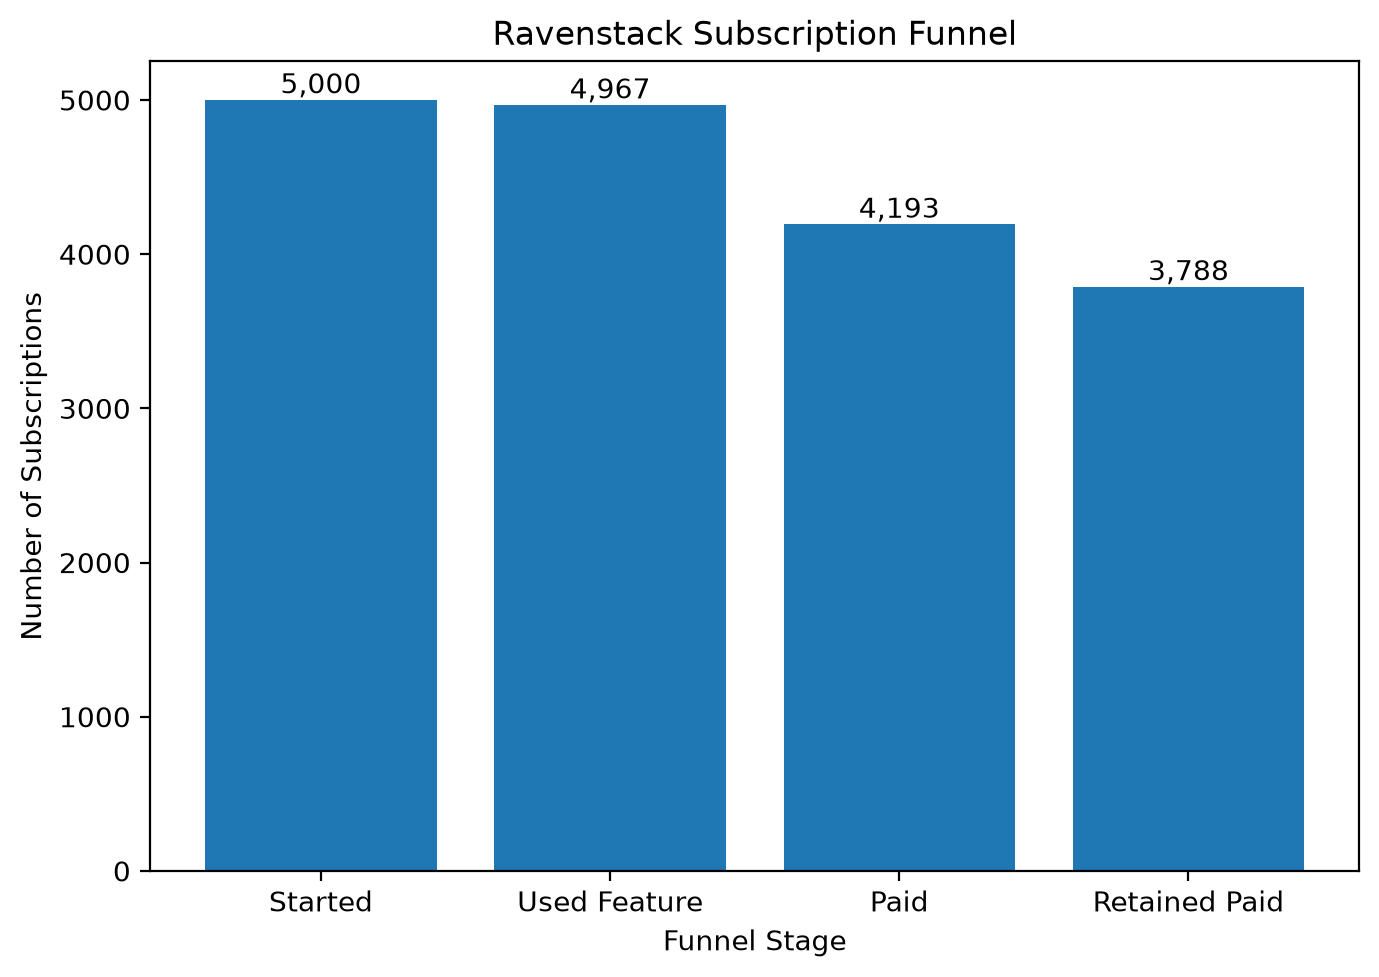


===== 가장 큰 이탈 구간 =====
Used Feature → Paid
전환율 : 84.42%
이탈률 : 15.58%
이탈 구독 수 : 774개


In [2]:
# 필수 1 코드를 작성하세요.


# ============================================================
# 1. 전체 구독 ID
# ============================================================

started_ids = set(subscriptions["subscription_id"].dropna().unique())


# ============================================================
# 2. 기능 사용 구독 ID
#    반드시 started_ids를 통과한 구독만 포함
# ============================================================

feature_used_ids = set(feature_usage["subscription_id"].dropna().unique())

used_ids = started_ids & feature_used_ids


# ============================================================
# 3. 유료 구독 ID
#    used_ids 중 체험판이 아닌 구독만 포함
# ============================================================

non_trial_ids = set(
    subscriptions.loc[
        subscriptions["is_trial"] == False,
        "subscription_id"
    ].dropna().unique()
)

paid_ids = used_ids & non_trial_ids


# ============================================================
# 4. 유지 중인 유료 구독 ID
#    paid_ids 중 종료일이 비어 있는 구독만 포함
# ============================================================

active_ids = set(
    subscriptions.loc[
        subscriptions["end_date"].isna(),
        "subscription_id"
    ].dropna().unique()
)

retained_paid_ids = paid_ids & active_ids


# ============================================================
# 5. Funnel 데이터프레임 생성
# ============================================================

funnel = pd.DataFrame({
    "stage": [
        "Started",
        "Used Feature",
        "Paid",
        "Retained Paid"
    ],
    
    "subscriptions": [
        len(started_ids),
        len(used_ids),
        len(paid_ids),
        len(retained_paid_ids)
    ]
})


# ============================================================
# 6. 구간별 전환율 / 이탈률
# ============================================================

funnel["conversion_rate"] = (
    funnel["subscriptions"]
    / funnel["subscriptions"].shift(1)
)

funnel["dropout_rate"] = (
    1 - funnel["conversion_rate"]
)


# 첫 단계는 이전 단계가 없으므로 NaN
funnel.loc[0, ["conversion_rate", "dropout_rate"]] = None


# ============================================================
# 7. 구간별 이탈 구독 수
# ============================================================

funnel["dropout_count"] = (
    funnel["subscriptions"].shift(1)
    - funnel["subscriptions"]
)

funnel.loc[0, "dropout_count"] = None


# 보기 좋게 % 단위 컬럼 추가
funnel["conversion_rate_pct"] = (
    funnel["conversion_rate"] * 100
).round(2)

funnel["dropout_rate_pct"] = (
    funnel["dropout_rate"] * 100
).round(2)


print(funnel)


# ============================================================
# 8. 단계별 구독 수 막대그래프
# ============================================================

plt.figure(figsize=(7, 5))

bars = plt.bar(funnel["stage"], funnel["subscriptions"])

plt.title("Ravenstack Subscription Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Subscriptions")


# 막대 위 숫자 표시
for bar, value in zip(bars, funnel["subscriptions"]):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )


plt.tight_layout()
plt.show()


# ============================================================
# 9. 전환율이 가장 낮은 구간 찾기
# ============================================================

lowest_idx = funnel["conversion_rate"].idxmin()

current_stage = funnel.loc[lowest_idx, "stage"]
previous_stage = funnel.loc[lowest_idx - 1, "stage"]

lowest_conversion = funnel.loc[lowest_idx, "conversion_rate_pct"]

highest_dropout = funnel.loc[lowest_idx, "dropout_rate_pct"]

dropout_count = int(funnel.loc[lowest_idx, "dropout_count"])


print("\n===== 가장 큰 이탈 구간 =====")
print(f"{previous_stage} → {current_stage}")
print(f"전환율 : {lowest_conversion:.2f}%")
print(f"이탈률 : {highest_dropout:.2f}%")
print(f"이탈 구독 수 : {dropout_count:,}개")

### 필수 1 답변 작성란

- **Q1.** 기능 사용 이벤트 행 수 대신 고유 구독 수를 사용해야 하는 이유는 무엇인가요?  
    - 같은 구독에서 기능 사용 이벤트가 여러번 발생할 수 있다.
    - 중복 계산될 위험성이 있다.

- **Q2.** 전환율이 가장 낮고 이탈 구독 수가 가장 많은 구간은 어디인가요?  
    - 기능사용 -> 유료 구독 구간, 전환율은 약 84.22%, 이탈 구독 수는 774개

- **Q3.** 전환율과 이탈률을 더하면 얼마인가요?  
    - 100%.
    - 이탈율 = 1 - 전환율로 계산

- **Q4.** 낮은 전환율만으로 실제 이탈 원인을 확정할 수 있나요?
    - 없다.
    - 퍼널은 사용자가 많이 줄어든 위치를 보여주지만, 성능, 가격, 기능부족 등 어떤 이유로 줄었는지는 원인파악이 추가로 필요하다.

---

## 필수 2. 요금제별 퍼널 비교하기

### 문제 2-1. 요금제에 따라 이탈 구간이 다른가?

#### 문제 설명

`Basic`, `Pro`, `Enterprise` 요금제별로 동일한 퍼널을 계산하고 구간 전환율을 비교하세요. 그룹별 비교를 통해 특정 요금제에 문제가 집중되어 있는지 확인합니다.

#### 요구사항

1. 요금제별 퍼널을 계산하는 함수 `calculate_segment_funnel()`을 작성하세요.
2. 함수는 필수 1과 동일한 네 단계의 고유 구독 수와 구간 전환율을 반환해야 합니다.
3. 세 요금제의 결과를 결합하여 `plan_funnel`을 만드세요.
4. 첫 단계를 제외한 구간별 전환율을 요금제별 막대그래프로 시각화하세요.
5. 모든 요금제와 구간의 조합 중 전환율이 가장 낮은 조합을 찾으세요.
6. 해당 요금제와 구간을 우선 점검 대상으로 정하고 개선 가설을 한 가지 제안하세요.
7. 요금제별 차이가 크지 않을 경우 해석에서 그 사실도 언급하세요.

#### 해석 질문

**Q1.** 전환율이 가장 낮은 요금제와 구간의 조합은 무엇인가요?  
**Q2.** 요금제별 퍼널 비교가 전체 퍼널만 보는 것보다 유용한 이유는 무엇인가요?  
**Q3.** 관찰된 요금제별 차이는 큰 편인가요?  
**Q4.** 개선 가설을 확인하기 위해 어떤 데이터를 추가로 살펴볼 수 있나요?

#### 제출 결과

- 요금제별 퍼널 계산 함수
- `plan_funnel` 결과
- 요금제별 전환율 그래프
- 우선 점검 대상과 개선 가설
- Q1~Q4 답변

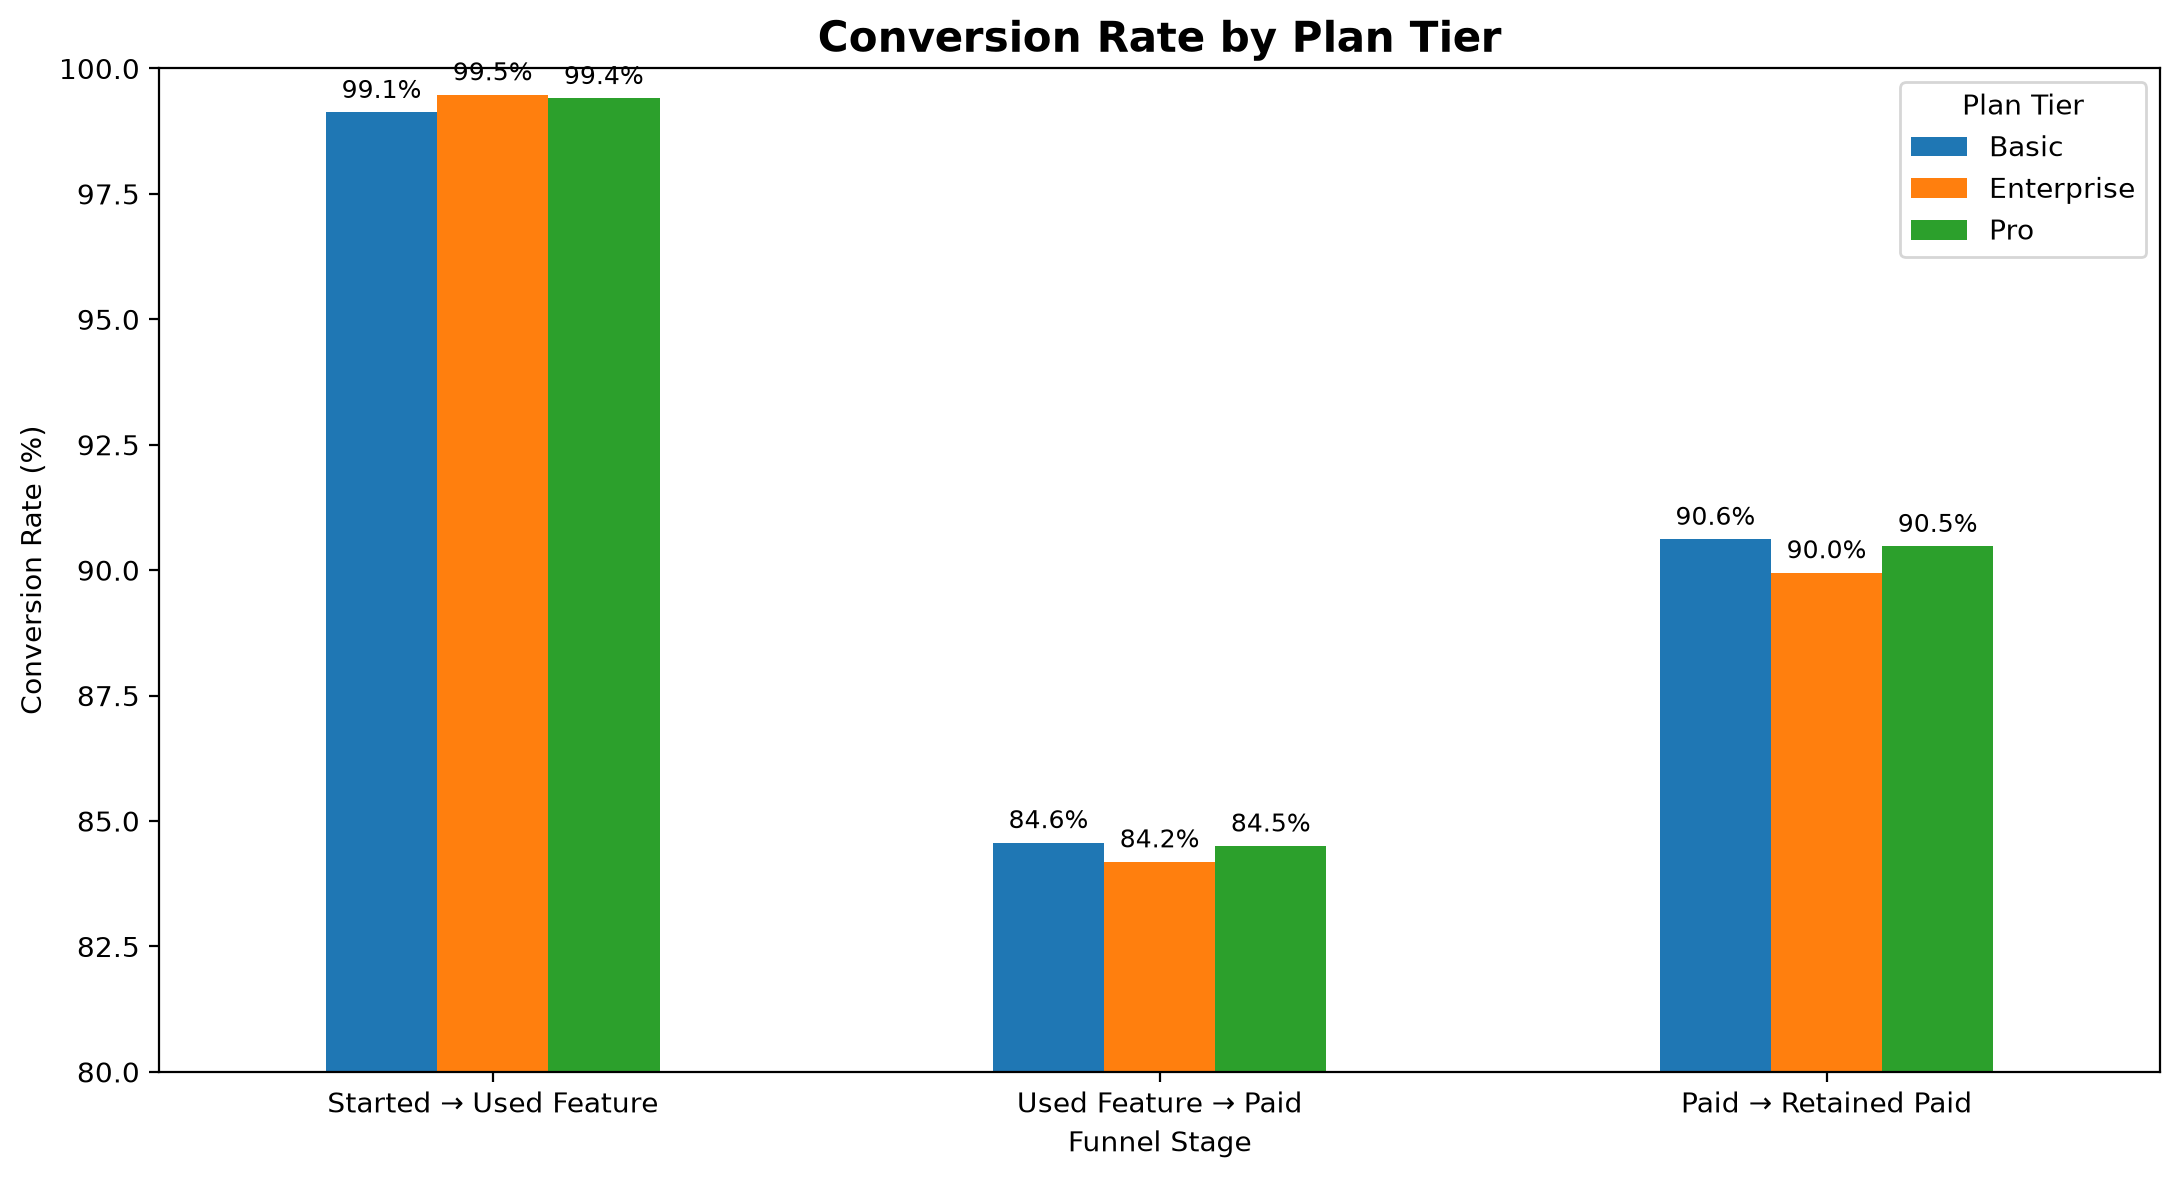

In [3]:
# 필수 2 코드를 작성하세요.

def calculate_segment_funnel(plan_name):

    # ============================================================
    # 1. 해당 요금제 데이터
    # ============================================================

    plan_subs = subscriptions[subscriptions["plan_tier"] == plan_name].copy()


    # ============================================================
    # 2. 구독 시작
    # ============================================================

    started_ids = set(plan_subs["subscription_id"].dropna().unique())


    # ============================================================
    # 3. 기능 사용
    # 기능 사용 기록이 한 번 이상 있는 고유 구독
    # ============================================================

    usage_ids = set(feature_usage["subscription_id"].dropna().unique())

    used_ids = started_ids & usage_ids


    # ============================================================
    # 4. 유료 구독
    # 기능 사용 구독 중 is_trial == False
    # ============================================================

    non_trial_ids = set(
        plan_subs.loc[plan_subs["is_trial"] == False, "subscription_id"]
        .dropna()
        .unique()
    )

    paid_ids = used_ids & non_trial_ids


    # ============================================================
    # 5. 현재 유료 유지
    # paid_ids 중 end_date가 비어 있는 구독
    # ============================================================

    active_ids = set(
        plan_subs.loc[
            plan_subs["end_date"].isna(),
            "subscription_id"
        ]
        .dropna()
        .unique()
    )

    retained_paid_ids = paid_ids & active_ids


    # ============================================================
    # 6. 퍼널 DataFrame
    # ============================================================

    funnel = pd.DataFrame({

        "plan_tier": plan_name,

        "stage": [
            "Started",
            "Used Feature",
            "Paid",
            "Retained Paid"
        ],

        "subscriptions": [
            len(started_ids),
            len(used_ids),
            len(paid_ids),
            len(retained_paid_ids)
        ]
    })


    # ============================================================
    # 7. 전환율
    # ============================================================

    funnel["conversion_rate"] = funnel["subscriptions"] / funnel["subscriptions"].shift(1)

    


    # 이탈률
    funnel["dropout_rate"] = 1 - funnel["conversion_rate"]


    # 이탈 구독 수
    funnel["dropout_count"] = (
        funnel["subscriptions"].shift(1)
        - funnel["subscriptions"]
    )


    return funnel

plans = [
    "Basic",
    "Pro",
    "Enterprise"
]

plan_funnel = pd.concat([calculate_segment_funnel(plan) for plan in plans], ignore_index=True)


plan_funnel["conversion_rate_pct"] = (plan_funnel["conversion_rate"] * 100).round(2)

plan_funnel["dropout_rate_pct"] = (plan_funnel["dropout_rate"] * 100).round(2)


stage_to_section = {
    "Used Feature": "Started → Used Feature",
    "Paid": "Used Feature → Paid",
    "Retained Paid": "Paid → Retained Paid"
}

plan_funnel["section"] = plan_funnel["stage"].map(stage_to_section)


# ==================================================================
# ================= 요금제별 구간 전환율 시각화 ======================
# ==================================================================


# 구간 이름 지정
stage_to_section = {
    "Used Feature": "Started → Used Feature",
    "Paid": "Used Feature → Paid",
    "Retained Paid": "Paid → Retained Paid"
}

plan_funnel["section"] = plan_funnel["stage"].map(stage_to_section)


# 첫 번째 단계 Started는 전환율이 없으므로 제외
plot_df = plan_funnel[plan_funnel["stage"] != "Started"].copy()


# 전환율을 %로 변환
plot_df["conversion_rate_pct"] = plot_df["conversion_rate"] * 100



# ==================================================================
# Pivot Table 생성
# ==================================================================

pivot_df = plot_df.pivot(
    index="section",
    columns="plan_tier",
    values="conversion_rate_pct"
)


# 구간 순서 지정
section_order = [
    "Started → Used Feature",
    "Used Feature → Paid",
    "Paid → Retained Paid"
]

pivot_df = pivot_df.reindex(section_order)


# ==================================================================
# 막대그래프
# ==================================================================

ax = pivot_df.plot(
    kind="bar",
    figsize=(11, 6),
    width=0.5
)


# 제목 / 축
plt.title(
    "Conversion Rate by Plan Tier",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Funnel Stage")
plt.ylabel("Conversion Rate (%)")


# y축 0 ~ 100%
plt.ylim(80, 100)


# x축 글씨 회전
plt.xticks(rotation=0)


# 범례
plt.legend(title="Plan Tier")


# ==================================================================
# 막대 위 전환율 표시
# ==================================================================

for container in ax.containers:

    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )


plt.tight_layout()
plt.show()

### 필수 2 답변 작성란

- **Q1.** 전환율이 가장 낮은 요금제와 구간의 조합은 무엇인가요?  
    - EnterPrise 요금제의 기능 사용 -> 유료 구독 구간, 전환율은 84.19%

- **Q2.** 요금제별 퍼널 비교가 전체 퍼널만 보는 것보다 유용한 이유는 무엇인가요?  
    - 전체 결과에서는 쉽게 볼 수 없는 특정 요금제의 상대적으로 낮은 구간을 찾을 수 있어 개선 대상을 더 구체적으로 정할 수 있음

- **Q3.** 관찰된 요금제별 차이는 큰 편인가요?  
    - 아닙니다.
    - 기능 사용에서 유료 구독으로 이어지는 전환율은 세 요금제 모두 약 84%정도로 차이가 작다.

- **Q4.** 개선 가설을 확인하기 위해 어떤 데이터를 추가로 살펴볼 수 있나요?
    - 체험 종료 데이터, 이탈 사유 데이터, 고객 문의 데이터 등


---

## 과제 1. 평가 문항 기반 독립 과제

### 문제 3-1. 결제 주기별 퍼널 비교하기

#### 문제 설명

월간 결제 구독과 연간 결제 구독의 퍼널을 비교하여 상대적으로 전환율이 낮은 그룹과 구간을 찾으세요.

> 이 과제는 필수 2에서 만든 함수와 분석 절차를 `billing_frequency`에 동일하게 적용하는 문제입니다.

#### 요구사항

1. `calculate_segment_funnel()`을 사용하여 `monthly`, `annual`의 퍼널을 계산하세요.
2. 두 결과를 결합하여 `billing_funnel`을 만드세요.
3. 첫 단계를 제외한 구간 전환율을 결제 주기별 막대그래프로 시각화하세요.
4. 모든 결제 주기와 구간의 조합 중 전환율이 가장 낮은 조합을 찾으세요.
5. 해당 그룹과 구간에 대한 개선 가설을 한 가지 제안하세요.
6. 퍼널 결과만으로 원인을 확정할 수 없는 이유와 추가 확인할 데이터를 설명하세요.

#### 해석 질문

**Q1.** 전환율이 가장 낮은 결제 주기와 구간의 조합은 무엇인가요?  
**Q2.** 해당 구간의 전환율과 이탈률은 얼마인가요?  
**Q3.** 이 결과만으로 결제 주기가 이탈의 원인이라고 말할 수 있나요?

#### 제출 결과

- `billing_funnel` 결과
- 결제 주기별 전환율 그래프
- 우선 점검 대상과 개선 가설
- 분석의 한계와 추가 확인 데이터
- Q1~Q3 답변

,billing_frequency,stage,subscriptions,conversion_rate,dropout_rate,dropout_count,conversion_rate_pct,dropout_rate_pct
0,monthly,Started,2539,NaN,NaN,NaN,NaN,NaN
1,monthly,Used Feature,2520,0.992517,0.007483,19.0,99.25,0.75
2,monthly,Paid,2120,0.841270,0.158730,400.0,84.13,15.87
3,monthly,Retained Paid,1930,0.910377,0.089623,190.0,91.04,8.96
4,annual,Started,2461,NaN,NaN,NaN,NaN,NaN
5,annual,Used Feature,2447,0.994311,0.005689,14.0,99.43,0.57
6,annual,Paid,2073,0.847160,0.152840,374.0,84.72,15.28
7,annual,Retained Paid,1858,0.896286,0.103714,215.0,89.63,10.37


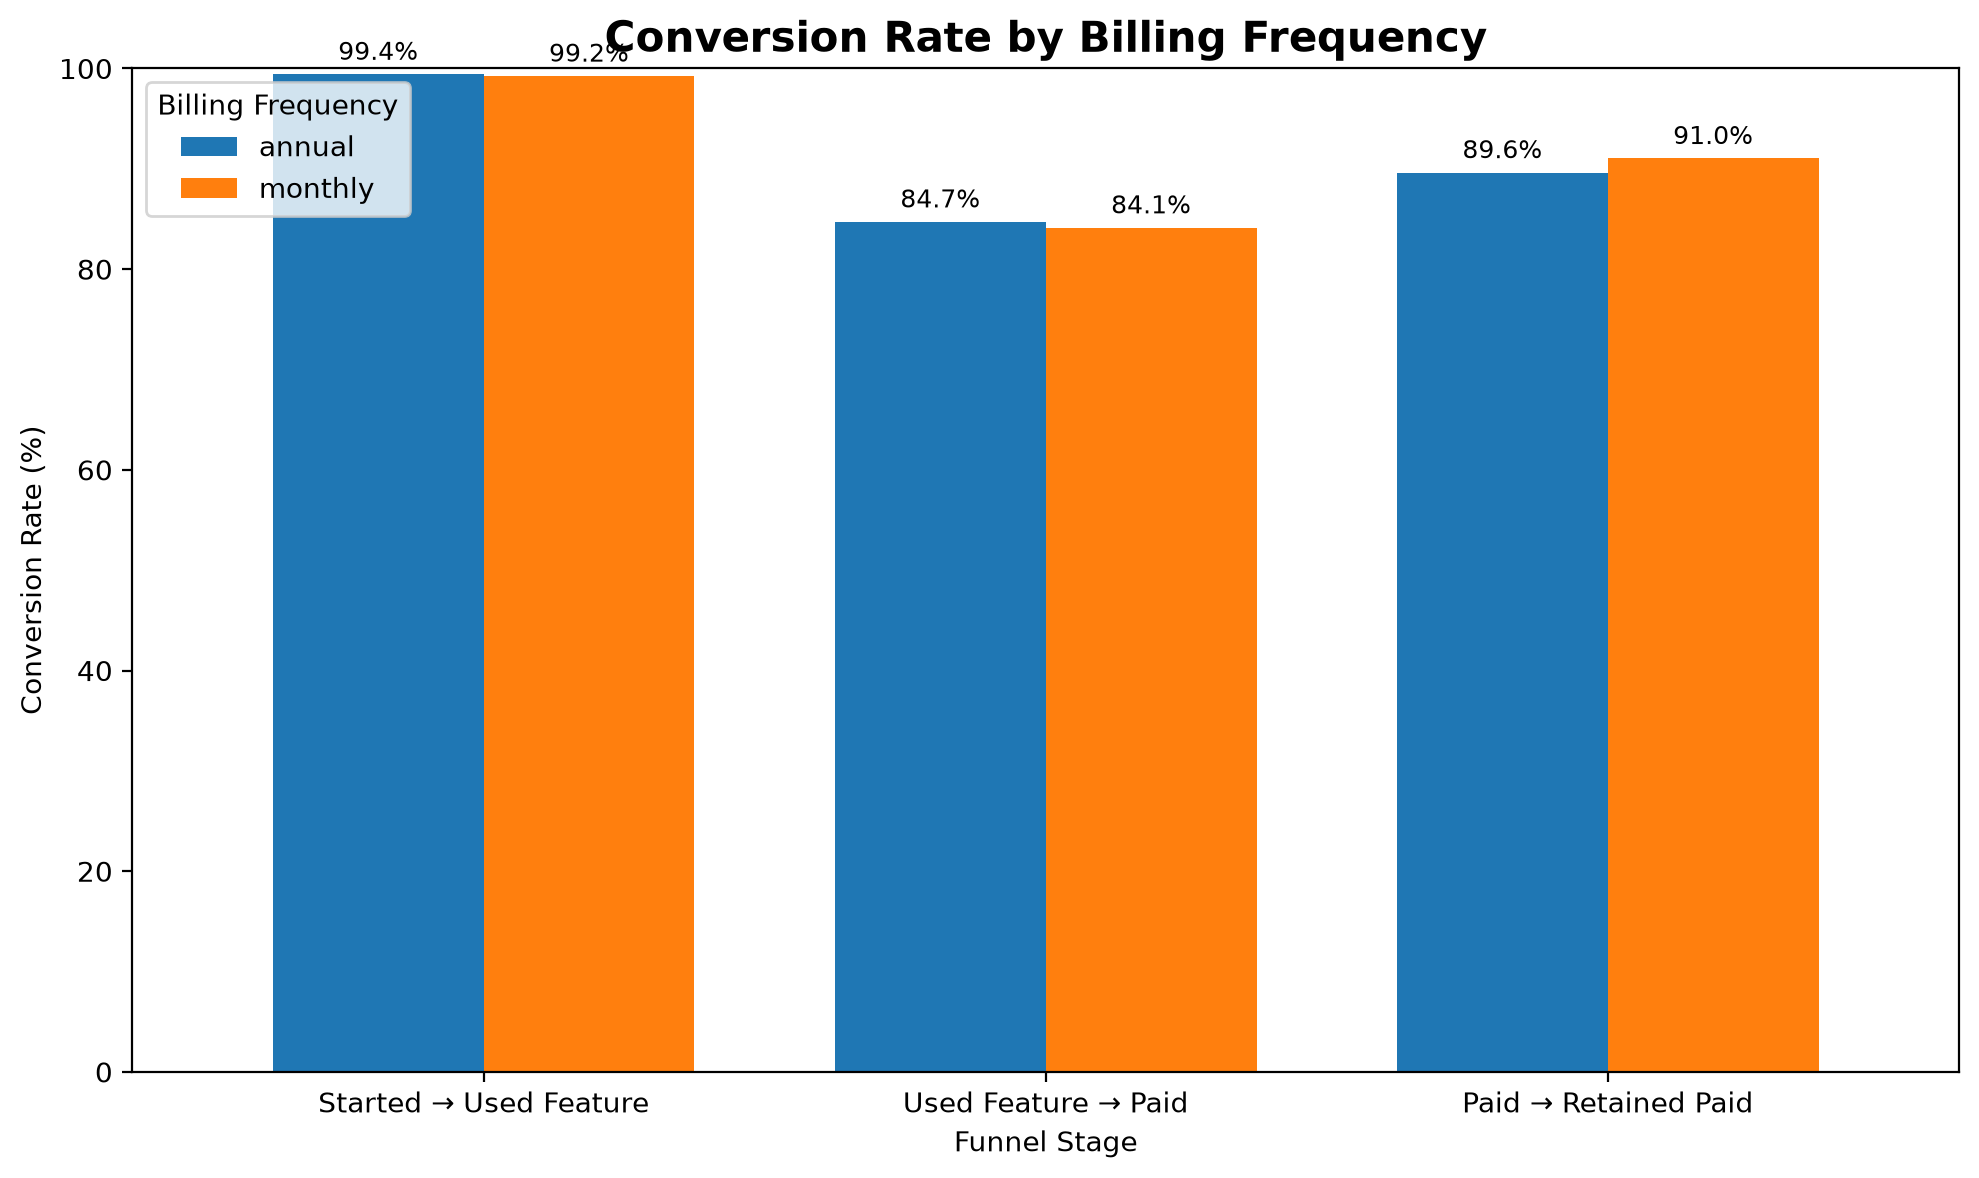

In [4]:
# 과제 1 코드를 작성하세요.

# ==================================================================
# ==================== 그룹별 퍼널 계산 함수 =========================
# ==================================================================

def calculate_segment_funnel(segment_col, segment_value):

    # --------------------------------------------------------------
    # 1. 해당 그룹의 구독 데이터
    # --------------------------------------------------------------
    segment_subs = subscriptions[
        subscriptions[segment_col] == segment_value
    ].copy()


    # --------------------------------------------------------------
    # 2. 구독 시작
    # --------------------------------------------------------------
    started_ids = set(
        segment_subs["subscription_id"]
        .dropna()
        .unique()
    )


    # --------------------------------------------------------------
    # 3. 기능 사용
    # started_ids 중 기능 사용 기록이 있는 구독
    # --------------------------------------------------------------
    usage_ids = set(
        feature_usage["subscription_id"]
        .dropna()
        .unique()
    )

    used_ids = started_ids & usage_ids


    # --------------------------------------------------------------
    # 4. 유료 구독
    # 기능 사용 구독 중 is_trial == False
    # --------------------------------------------------------------
    non_trial_ids = set(
        segment_subs.loc[
            segment_subs["is_trial"] == False,
            "subscription_id"
        ]
        .dropna()
        .unique()
    )

    paid_ids = used_ids & non_trial_ids


    # --------------------------------------------------------------
    # 5. 현재 유료 유지
    # 유료 구독 중 end_date가 비어 있는 구독
    # --------------------------------------------------------------
    active_ids = set(
        segment_subs.loc[
            segment_subs["end_date"].isna(),
            "subscription_id"
        ]
        .dropna()
        .unique()
    )

    retained_paid_ids = paid_ids & active_ids


    # --------------------------------------------------------------
    # 6. Funnel DataFrame
    # --------------------------------------------------------------
    funnel = pd.DataFrame({

        "segment": segment_value,

        "stage": [
            "Started",
            "Used Feature",
            "Paid",
            "Retained Paid"
        ],

        "subscriptions": [
            len(started_ids),
            len(used_ids),
            len(paid_ids),
            len(retained_paid_ids)
        ]
    })


    # --------------------------------------------------------------
    # 7. 전환율
    # --------------------------------------------------------------
    funnel["conversion_rate"] = (
        funnel["subscriptions"]
        / funnel["subscriptions"].shift(1)
    )


    # 이탈률
    funnel["dropout_rate"] = (
        1 - funnel["conversion_rate"]
    )


    # 이탈 구독 수
    funnel["dropout_count"] = (
        funnel["subscriptions"].shift(1)
        - funnel["subscriptions"]
    )


    return funnel

# ==================================================================
# ==================== 결제 주기별 Funnel ============================
# ==================================================================

billing_types = [
    "monthly",
    "annual"
]


billing_funnel = pd.concat(
    [
        calculate_segment_funnel(
            "billing_frequency",
            billing
        )
        for billing in billing_types
    ],
    ignore_index=True
)


# 컬럼명 변경
billing_funnel = billing_funnel.rename(
    columns={
        "segment": "billing_frequency"
    }
)


# 전환율 / 이탈률 %
billing_funnel["conversion_rate_pct"] = (
    billing_funnel["conversion_rate"] * 100
).round(2)

billing_funnel["dropout_rate_pct"] = (
    billing_funnel["dropout_rate"] * 100
).round(2)

display(billing_funnel)

# 결제주기별 구간 전환율 시각화
# ==================================================================
# ========================= 구간 이름 생성 ===========================
# ==================================================================

stage_to_section = {
    "Used Feature": "Started → Used Feature",
    "Paid": "Used Feature → Paid",
    "Retained Paid": "Paid → Retained Paid"
}


billing_funnel["section"] = (
    billing_funnel["stage"].map(stage_to_section)
)


# Started는 이전 단계가 없기 때문에 제외
plot_df = billing_funnel[
    billing_funnel["stage"] != "Started"
].copy()


# ==================================================================
# ========================== Pivot Table =============================
# ==================================================================

pivot_df = plot_df.pivot(
    index="section",
    columns="billing_frequency",
    values="conversion_rate_pct"
)


# 퍼널 순서 지정
section_order = [
    "Started → Used Feature",
    "Used Feature → Paid",
    "Paid → Retained Paid"
]

pivot_df = pivot_df.reindex(section_order)


# ==================================================================
# ============================ 시각화 ================================
# ==================================================================

ax = pivot_df.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75
)


plt.title(
    "Conversion Rate by Billing Frequency",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Funnel Stage")
plt.ylabel("Conversion Rate (%)")

plt.ylim(0, 100)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Billing Frequency"
)


# 막대 위 % 표시
for container in ax.containers:

    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )


plt.tight_layout()
plt.show()

### 과제 1 답변 작성란

- **Q1.** 전환율이 가장 낮은 결제 주기와 구간의 조합은 무엇인가요?  
    - 전환율이 가장 낮은 결제 주기는 monthly(월별) 결제 방식 이며,
    - 기능 사용 -> 유로구독의 구간에서 가장 낮게 나타난다.

- **Q2.** 해당 구간의 전환율과 이탈률은 얼마인가요?  
    - 해당 구간의 전환율은 84.1% 이며,
    - 이탈률은 100-전환율이므로 15.9% 이다.

- *Q3.** 이 결과만으로 결제 주기가 이탈의 원인이라고 말할 수 있나요?
    - 아니요.
    - 이 결과는 연관성을 보여줄 수는 있지만 결제주기와 이탈의 인과관계를 단정지을 수는 없다.

---

## 실습 마무리

아래 질문에 답하세요.

1. 이번 실습의 퍼널 단계를 어떻게 정의했나요?
    - 구독여부 -> 기능 사용 여부 -> 유료 구독으로 전환 -> 구독 유지 여부(종료 DATE가 없는)
    - 4단계로 분류

2. 단계별 사용자 수 대신 어떤 식별자의 고유 개수를 사용했나요?
    - 구독자 ID의 고유값을 사용했다.

3. 전환율과 이탈률은 어떻게 계산했나요?
    - 전환율 =  현재 단계 구독 수 / 이전 단계 구독 수
    - 이탈률 = 100 - 전환율

4. 전체 퍼널에서 가장 큰 문제가 나타난 구간은 어디였나요?
    - 기능 -> 유료 구독 약 84%의 전환율, 이탈률은 16%

5. 퍼널 분석 결과와 실제 원인을 왜 구분해야 하나요?
    - 퍼널은 어느 구간에서 사용자가 줄었는지 보여주지만
    - 가격, 기능, 문의 등 어떤 요인이 원인이었는지 직접적으로 알려주지는 않는다.
